In [1]:
from data_preparation import prepare_dataset, get_loss_weights
from graph_construction import build_graph
from train_and_evaluate import (
    train_and_evaluate,
    train_mlp
)
from models import (
    BaselineMLP,
    GoldenTransformer
)
from resources import (
    DATA_PATH,
    DEVICE,
    OUTPUT_TABLES_PATH,
    OUTPUT_FIGURES_PATH,
    MODELS_PATH
)

EPOCHS = 500
PATIENCE = 30

c:\Users\Mislav.FERIT-PC\Desktop\multirelational-graph-topology-for-downstream-wildfire-tasks\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import torch
import os
import numpy as np

In [3]:
x, y, pos_combined, pos_spatial, pos_temporal, group_ids = prepare_dataset(DATA_PATH, return_group_ids=True)
class_weights = get_loss_weights(y = y)

There are 10034 natural fires (56.44 %) [all]
There are 7744 human made fires (43.56 %) [all]


In [4]:
mlp_topology_comparison_df = pd.read_csv(os.path.join(OUTPUT_TABLES_PATH, "mlp_topology_comparison.csv"))
topology_comparison_df = pd.read_csv(os.path.join(OUTPUT_TABLES_PATH, "topology_comparison_df.csv"))

# FULL FEATURE INTEGRATION

## Finding the Best Transformer

In [5]:
head_list=[2, 4, 8]
k_list=[5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35]

In [6]:
import numpy as np
import random


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_golden_integrated_study(head_list, k_list, grid_seeds=(101, 202, 303)):
    print("\n" + "="*60)
    print("STAGE 3: GOLDEN GRID SEARCH (HEADS x K) - FULL CAUSAL INTEGRITY")
    print("="*60)

    # 1. Prepare Full Features [Log-Area, Season_Sin, Season_Cos, Lat, Lon, Days]
    # Ensure all are on the same device and correctly shaped
    log_area_t = x.to(DEVICE) if x.dim() == 2 else x.unsqueeze(1).to(DEVICE)
    x_full = torch.cat([
        log_area_t, 
        pos_spatial.to(DEVICE), 
        pos_temporal.to(DEVICE)
    ], dim=1)

    final_results = []

    for k in k_list:
        data_k = build_graph('multirelational', k, pos_spatial, pos_temporal, pos_combined, x_full, y, group_ids=group_ids)
        data_k = data_k.to(DEVICE)
        
        in_dim = data_k.x.size(1)       
        e_dim = data_k.edge_attr.size(1) 

        for h in head_list:
            print(f"\n>>> Training: multirelational K={k} | Heads={h} | Dim: {in_dim} in / {e_dim} edge")

            # Average over several seeds so the champion is picked by a robust
            # mean F1 rather than a single noisy run; unstable configs (which
            # collapse on some seeds) self-deprioritize via the lower mean.
            seed_f1s, seed_accs = [], []
            for seed in grid_seeds:
                set_seed(seed)
                model = GoldenTransformer(
                    input_dim=in_dim, 
                    hidden_dim=16, 
                    edge_dim=e_dim, 
                    num_heads=h
                )
                f1, acc, __ = train_and_evaluate(model, data_k, DEVICE, class_weights, max_epochs=500, patience=30)
                seed_f1s.append(f1)
                seed_accs.append(acc)

            f1_mean, f1_std = float(np.mean(seed_f1s)), float(np.std(seed_f1s))
            acc_mean = float(np.mean(seed_accs))
            print(f"RESULTS | K: {k:<2} | Heads: {h:<2} | F1: {f1_mean:.4f} +/- {f1_std:.4f} | Acc: {acc_mean:.4f}")

            final_results.append({
                'K': k,
                'Heads': h,
                'Model': f'Transformer_{h}H_K{k}',
                'F1': f1_mean,
                'F1_std': f1_std,
                'Accuracy': acc_mean
            })

    # 3. Summary and Comparison vs Best MLP
    best_transformer_df = pd.DataFrame(final_results)
    best_gnn = best_transformer_df.sort_values(by='F1', ascending=False).iloc[0]

    mlp_subset = mlp_topology_comparison_df[mlp_topology_comparison_df['Model'] == 'MLP']
    if not mlp_subset.empty:
        mlp_best = mlp_subset.sort_values(by='F1', ascending=False).iloc[0]

        print("\n" + "="*60)
        print("FINAL COMPETITIVE SUMMARY: GNN vs. BASELINE")
        print("-" * 60)
        print(f"Best MLP Baseline F1:     {mlp_best['F1']:.4f}")
        print(f"Golden GNN Winner F1:     {best_gnn['F1']:.4f} +/- {best_gnn['F1_std']:.4f} (K={best_gnn['K']}, Heads={best_gnn['Heads']})")
        
        f1_lift = best_gnn['F1'] - mlp_best['F1']
        
        print(f"Total F1 Score Lift:      {f1_lift*100:+.2f}%")
        print("="*60)
    
    return best_transformer_df

best_transformer_df = run_golden_integrated_study(
    head_list=head_list,
    k_list=k_list
)
best_transformer_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "best_transformer_df.csv"))


STAGE 3: GOLDEN GRID SEARCH (HEADS x K) - FULL CAUSAL INTEGRITY

>>> Training: multirelational K=5 | Heads=2 | Dim: 4 in / 4 edge
RESULTS | K: 5  | Heads: 2  | F1: 0.6591 +/- 0.0029 | Acc: 0.6734

>>> Training: multirelational K=5 | Heads=4 | Dim: 4 in / 4 edge
RESULTS | K: 5  | Heads: 4  | F1: 0.6475 +/- 0.0016 | Acc: 0.6674

>>> Training: multirelational K=5 | Heads=8 | Dim: 4 in / 4 edge
RESULTS | K: 5  | Heads: 8  | F1: 0.6539 +/- 0.0102 | Acc: 0.6654

>>> Training: multirelational K=7 | Heads=2 | Dim: 4 in / 4 edge
RESULTS | K: 7  | Heads: 2  | F1: 0.6730 +/- 0.0081 | Acc: 0.6886

>>> Training: multirelational K=7 | Heads=4 | Dim: 4 in / 4 edge
RESULTS | K: 7  | Heads: 4  | F1: 0.6627 +/- 0.0047 | Acc: 0.6779

>>> Training: multirelational K=7 | Heads=8 | Dim: 4 in / 4 edge
RESULTS | K: 7  | Heads: 8  | F1: 0.6697 +/- 0.0093 | Acc: 0.6873

>>> Training: multirelational K=9 | Heads=2 | Dim: 4 in / 4 edge
RESULTS | K: 9  | Heads: 2  | F1: 0.6869 +/- 0.0026 | Acc: 0.7006

>>> Traini

## Best MLP vs Best GNN (Full Node Features): Multi-Metric Comparison

In [7]:
best_transformer_df = pd.read_csv(os.path.join(OUTPUT_TABLES_PATH, "best_transformer_df.csv"))

In [8]:
x_mlp_spatial = torch.cat([x, pos_spatial], dim=1)        
x_mlp_temporal = torch.cat([x, pos_temporal], dim=1)        
x_mlp_combined = torch.cat([x, pos_spatial, pos_temporal], dim=1) 

In [13]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, matthews_corrcoef, balanced_accuracy_score
import random
import numpy as np
import torch

def run_automated_showdown(model_name, seeds, best_transformer_df, mlp_topology_comparison_df, x_mlp_combined, x_mlp_spatial, x_mlp_temporal, num_runs=10):
    log_area_t = x.to(DEVICE) if x.dim() == 2 else x.unsqueeze(1).to(DEVICE)
    x_full = torch.cat([
        log_area_t, 
        pos_spatial.to(DEVICE), 
        pos_temporal.to(DEVICE)
    ], dim=1)

    print("\n" + "!"*60)
    print(f"STAGE 4: FINAL COMPARISON (N={num_runs})")
    print("!"*60)

    # 1. IDENTIFY BEST MODELS
    best_gnn_row = best_transformer_df.sort_values(by='F1', ascending=False).iloc[0]
    best_k, best_h = int(best_gnn_row['K']), int(best_gnn_row['Heads'])
    
    best_mlp_row = mlp_topology_comparison_df[mlp_topology_comparison_df['Model'] == 'MLP'].sort_values(by='F1', ascending=False).iloc[0]
    best_mlp_type = best_mlp_row['Graph']

    mlp_feature_map = {
        'MLP_Combined': (x_mlp_combined, x_mlp_combined.size(1)),
        'MLP_Spatial': (x_mlp_spatial, x_mlp_spatial.size(1)),
        'MLP_Temporal': (x_mlp_temporal, x_mlp_temporal.size(1))
    }
    mlp_features, mlp_in_dim = mlp_feature_map[best_mlp_type]

    print(f"\n[CHAMPIONS]")
    print(f"GNN: Transformer (K={best_k}, Heads={best_h})")
    print(f"MLP: {best_mlp_type} (Input Dim={mlp_in_dim})")

    # 2. INITIALIZE RESULTS STORAGE
    # We track 5 metrics for both models
    metrics = ['F1', 'Acc', 'Balanced_Acc', 'AUC', 'MCC']
    results = {model: {m: [] for m in metrics} for model in ['GNN', 'MLP']}
    
    data_final = build_graph('multirelational', best_k, pos_spatial, pos_temporal, pos_combined, x_full, y, group_ids=group_ids).to(DEVICE)
    train_mask = data_final.train_mask.to(DEVICE)
    val_mask = data_final.val_mask.to(DEVICE)
    test_mask = data_final.test_mask.to(DEVICE)

    # 3. THE COMPARISON
    best_gnn_f1 = 0.0
    best_gnn = None
    for i in range(num_runs):
        seed = seeds[i]
        
        # GNN Evaluation
        set_seed(seed)
        model_gnn = GoldenTransformer(
            input_dim=data_final.x.size(1), 
            hidden_dim=16, 
            edge_dim=data_final.edge_attr.size(1), 
            num_heads=best_h
        ).to(DEVICE)
        
        _, _, trained_gnn = train_and_evaluate(model_gnn, data_final, DEVICE, class_weights, max_epochs=500, patience=30)
        
        gnn_m = calculate_binary_metrics(trained_gnn, data_final, test_mask, is_gnn=True)
        if gnn_m['F1'] > best_gnn_f1:
            best_gnn_f1 = gnn_m['F1']
            best_gnn = trained_gnn
        for m in metrics: results['GNN'][m].append(gnn_m[m])

        # MLP Evaluation
        set_seed(seed)
        model_mlp = BaselineMLP(input_dim=mlp_in_dim, hidden_dim=16).to(DEVICE)
        _, _, trained_mlp = train_mlp(model_mlp, mlp_features, y, train_mask, val_mask, test_mask, DEVICE, class_weights)
        
        mlp_m = calculate_binary_metrics(trained_mlp, (mlp_features, y), test_mask, is_gnn=False)
        for m in metrics: results['MLP'][m].append(mlp_m[m])
        
        print(f"Run {i+1}/{num_runs} | Seed {seed} | GNN F1: {gnn_m['F1']:.4f} | MLP F1: {mlp_m['F1']:.4f}")

    # 4. FINAL REPORTING
    print("\n" + "="*65)
    print(f"{'Metric':<15} | {'Best MLP (Mean +/- SD)':<25} | {'Golden GNN (Mean +/- SD)':<25}")
    print("-" * 65)
    
    final_summary = {}
    for m in metrics:
        g_mean, g_std = np.mean(results['GNN'][m]), np.std(results['GNN'][m])
        m_mean, m_std = np.mean(results['MLP'][m]), np.std(results['MLP'][m])
        final_summary[m] = (g_mean, g_std, m_mean, m_std)
        print(f"{m:<15} | {m_mean:.4f} +/- {m_std:.4f} | {g_mean:.4f} +/- {g_std:.4f}")
    
    lift = ((final_summary['F1'][0] - final_summary['F1'][2]) / final_summary['F1'][2]) * 100
    print("-" * 65)
    print(f"Relative F1 Lift: {lift:+.2f}%")
    print("="*65)

    torch.save(best_gnn.state_dict(), os.path.join(MODELS_PATH, model_name + "_weights.pth"))

    return results, final_summary

def calculate_binary_metrics(model, data_obj, mask, is_gnn=True):
    """ Helper to compute all 5 metrics for a trained model """
    model.eval()
    device = next(model.parameters()).device
    
    with torch.no_grad():
        if is_gnn:
            data_obj = data_obj.to(device)
            logits = model(data_obj.x, data_obj.edge_index, data_obj.edge_attr)
            y_true = data_obj.y[mask].cpu().numpy()
        else:
            features, y_all = data_obj
            features = features.to(device)
            y_all = y_all.to(device)       
            
            logits = model(features)
            y_true = y_all[mask].cpu().numpy()
            
        probs = torch.softmax(logits[mask], dim=1)[:, 1].cpu().numpy()
        preds = logits[mask].argmax(dim=1).cpu().numpy()

    return {
        'F1': f1_score(y_true, preds, average='macro'),
        'Acc': accuracy_score(y_true, preds),
        'Balanced_Acc': balanced_accuracy_score(y_true, preds),
        'AUC': roc_auc_score(y_true, probs),
        'MCC': matthews_corrcoef(y_true, preds)
    }

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

def plot_final_showdown(showdown_results, prefix, OUTPUT_FIGURES_PATH):
    if not os.path.exists(OUTPUT_FIGURES_PATH):
        os.makedirs(OUTPUT_FIGURES_PATH)

    # 1. Transform dictionary results into a Long-Format DataFrame
    plot_data = []
    for model_name, metrics_dict in showdown_results.items():
        for metric_name, values in metrics_dict.items():
            for val in values:
                plot_data.append({
                    'Model': 'Proposed GNN' if model_name == 'GNN' else 'Baseline MLP',
                    'Metric': metric_name.replace('_', ' '),
                    'Score': val
                })
    
    df_plot = pd.DataFrame(plot_data)

    # ==========================================
    # GLOBAL PAPER-READY STYLING
    # ==========================================
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 18,
        'axes.labelsize': 20,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 16,
        'axes.linewidth': 1.5,
        'figure.dpi': 300,
        'savefig.bbox': 'tight'
    })
    sns.set_theme(style="whitegrid", font="serif")
    
    # ---------------------------------------------------------
    # PLOT A: COMPREHENSIVE METRIC SHOWDOWN
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Using 'edgecolor' and 'linewidth' makes bars look much sharper in PDFs
    sns.barplot(
        data=df_plot, 
        x='Metric', 
        y='Score', 
        hue='Model', 
        palette=['#4285F4', '#777777'], # Professional Blue vs Neutral Grey
        capsize=.08,
        errwidth=2.0,
        edgecolor='black',
        linewidth=1.2,
        ax=ax
    )
    
    # Adjust labels for clarity
    ax.set_ylabel("Metric Score", fontweight='bold')
    ax.set_xlabel("Evaluation Metrics", fontweight='bold')
    
    # Zooming in makes the performance gap more visible
    ymin = max(0, df_plot['Score'].min() - 0.1)
    ax.set_ylim(ymin, 1.0)
    
    # Refining the legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), 
              ncol=2, frameon=True, fancybox=False, shadow=False)

    # Optional: Adding a light horizontal grid for better value estimation
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    plt.savefig(os.path.join(OUTPUT_FIGURES_PATH, prefix + "full_node_features_best_gnn_metrics.png"))
    plt.show()

    print(f"\n--- Final showdown plots saved to {OUTPUT_FIGURES_PATH} ---")

In [15]:
showdown_results, summary = run_automated_showdown(
    "best_full_features_no_seasonal",
    [111, 222, 333, 444, 555, 666, 777, 888, 999, 1111],
    best_transformer_df, 
    mlp_topology_comparison_df, 
    x_mlp_combined, 
    x_mlp_spatial, 
    x_mlp_temporal, 
    num_runs=10
)

print("\n[SUMMARY TABLE]")
best_mlp_vs_full_feature_best_gnn_df = pd.DataFrame(summary, index=['GNN_Mean', 'GNN_SD', 'MLP_Mean', 'MLP_SD']).T
best_mlp_vs_full_feature_best_gnn_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "best_mlp_vs_full_feature_best_gnn_df.csv"))


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STAGE 4: FINAL COMPARISON (N=10)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

[CHAMPIONS]
GNN: Transformer (K=27, Heads=8)
MLP: MLP_Spatial (Input Dim=3)
Run 1/10 | Seed 111 | GNN F1: 0.7128 | MLP F1: 0.5854
Run 2/10 | Seed 222 | GNN F1: 0.6995 | MLP F1: 0.5813
Run 3/10 | Seed 333 | GNN F1: 0.3720 | MLP F1: 0.5846
Run 4/10 | Seed 444 | GNN F1: 0.7083 | MLP F1: 0.5300
Run 5/10 | Seed 555 | GNN F1: 0.7059 | MLP F1: 0.5974
Run 6/10 | Seed 666 | GNN F1: 0.7116 | MLP F1: 0.5307
Run 7/10 | Seed 777 | GNN F1: 0.7047 | MLP F1: 0.5966
Run 8/10 | Seed 888 | GNN F1: 0.7059 | MLP F1: 0.5192
Run 9/10 | Seed 999 | GNN F1: 0.7046 | MLP F1: 0.6106
Run 10/10 | Seed 1111 | GNN F1: 0.7135 | MLP F1: 0.5268

Metric          | Best MLP (Mean +/- SD)    | Golden GNN (Mean +/- SD) 
-----------------------------------------------------------------
F1              | 0.5662 +/- 0.0334 | 0.6739 +/- 0.1007
Acc             | 0.6092 +/- 0

C:\Users\Mislav.FERIT-PC\AppData\Local\Temp\ipykernel_40432\254728913.py:45: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.barplot(


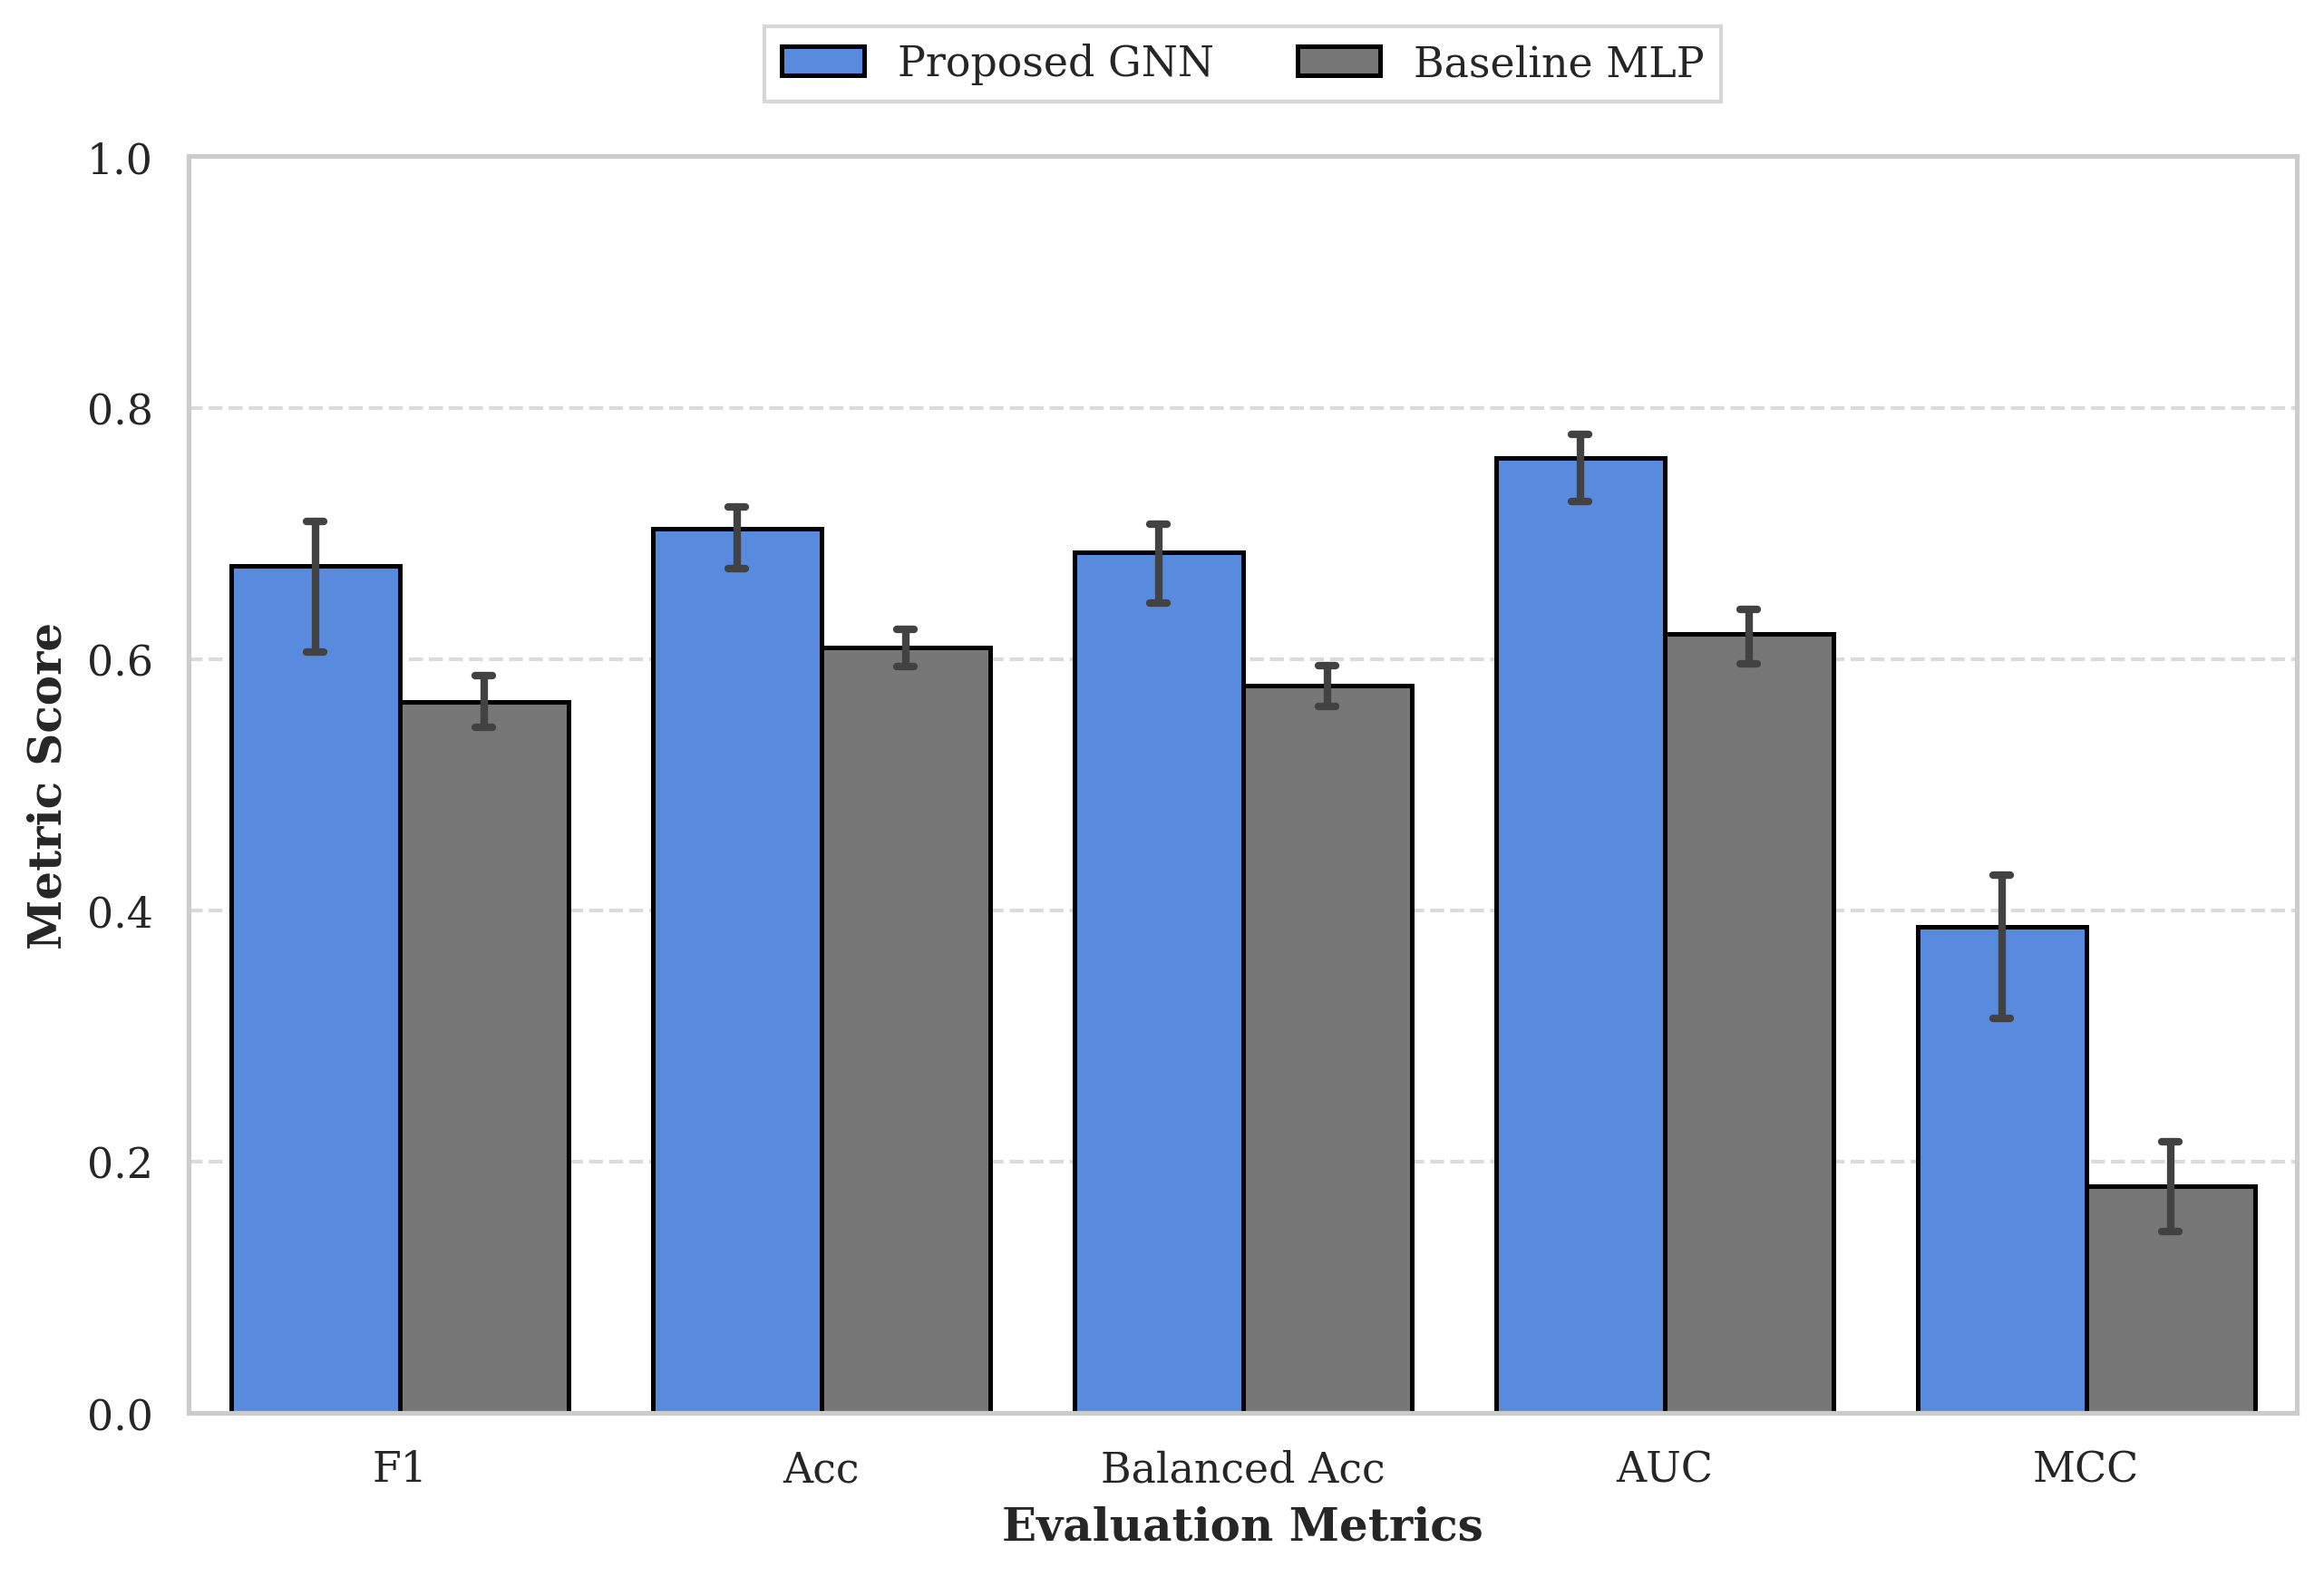


--- Final showdown plots saved to ./outputs\figures ---


In [16]:
plot_final_showdown(showdown_results, "", OUTPUT_FIGURES_PATH)

## Best MLP vs Best GNN (No seasonal features - without collapsing seed 666): Multi-Metric Comparison

In [21]:
showdown_results_no_collapse, summary_no_collapse = run_automated_showdown(
    "best_full_features_no_seasonal_no_collapse",
    [99, 111, 222, 444, 555, 666, 777, 888, 999, 1111],
    best_transformer_df, 
    mlp_topology_comparison_df, 
    x_mlp_combined, 
    x_mlp_spatial, 
    x_mlp_temporal, 
    num_runs=10
)

print("\n[SUMMARY TABLE]")
best_mlp_vs_full_feature_best_gnn_no_collapse_df = pd.DataFrame(summary_no_collapse, index=['GNN_Mean', 'GNN_SD', 'MLP_Mean', 'MLP_SD']).T
best_mlp_vs_full_feature_best_gnn_no_collapse_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "best_mlp_vs_full_feature_best_gnn_df.csv"))


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
STAGE 4: FINAL COMPARISON (N=10)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

[CHAMPIONS]
GNN: Transformer (K=27, Heads=8)
MLP: MLP_Spatial (Input Dim=3)
Run 1/10 | Seed 99 | GNN F1: 0.7109 | MLP F1: 0.5290
Run 2/10 | Seed 111 | GNN F1: 0.7171 | MLP F1: 0.5854
Run 3/10 | Seed 222 | GNN F1: 0.7118 | MLP F1: 0.5813
Run 4/10 | Seed 444 | GNN F1: 0.7023 | MLP F1: 0.5300
Run 5/10 | Seed 555 | GNN F1: 0.7065 | MLP F1: 0.5974
Run 6/10 | Seed 666 | GNN F1: 0.7087 | MLP F1: 0.5307
Run 7/10 | Seed 777 | GNN F1: 0.7089 | MLP F1: 0.5966
Run 8/10 | Seed 888 | GNN F1: 0.7076 | MLP F1: 0.5192
Run 9/10 | Seed 999 | GNN F1: 0.7031 | MLP F1: 0.6106
Run 10/10 | Seed 1111 | GNN F1: 0.7016 | MLP F1: 0.5268

Metric          | Best MLP (Mean +/- SD)    | Golden GNN (Mean +/- SD) 
-----------------------------------------------------------------
F1              | 0.5607 +/- 0.0345 | 0.7078 +/- 0.0045
Acc             | 0.6060 +/- 0.

C:\Users\Mislav.FERIT-PC\AppData\Local\Temp\ipykernel_40432\254728913.py:45: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2.0}` instead.

  sns.barplot(


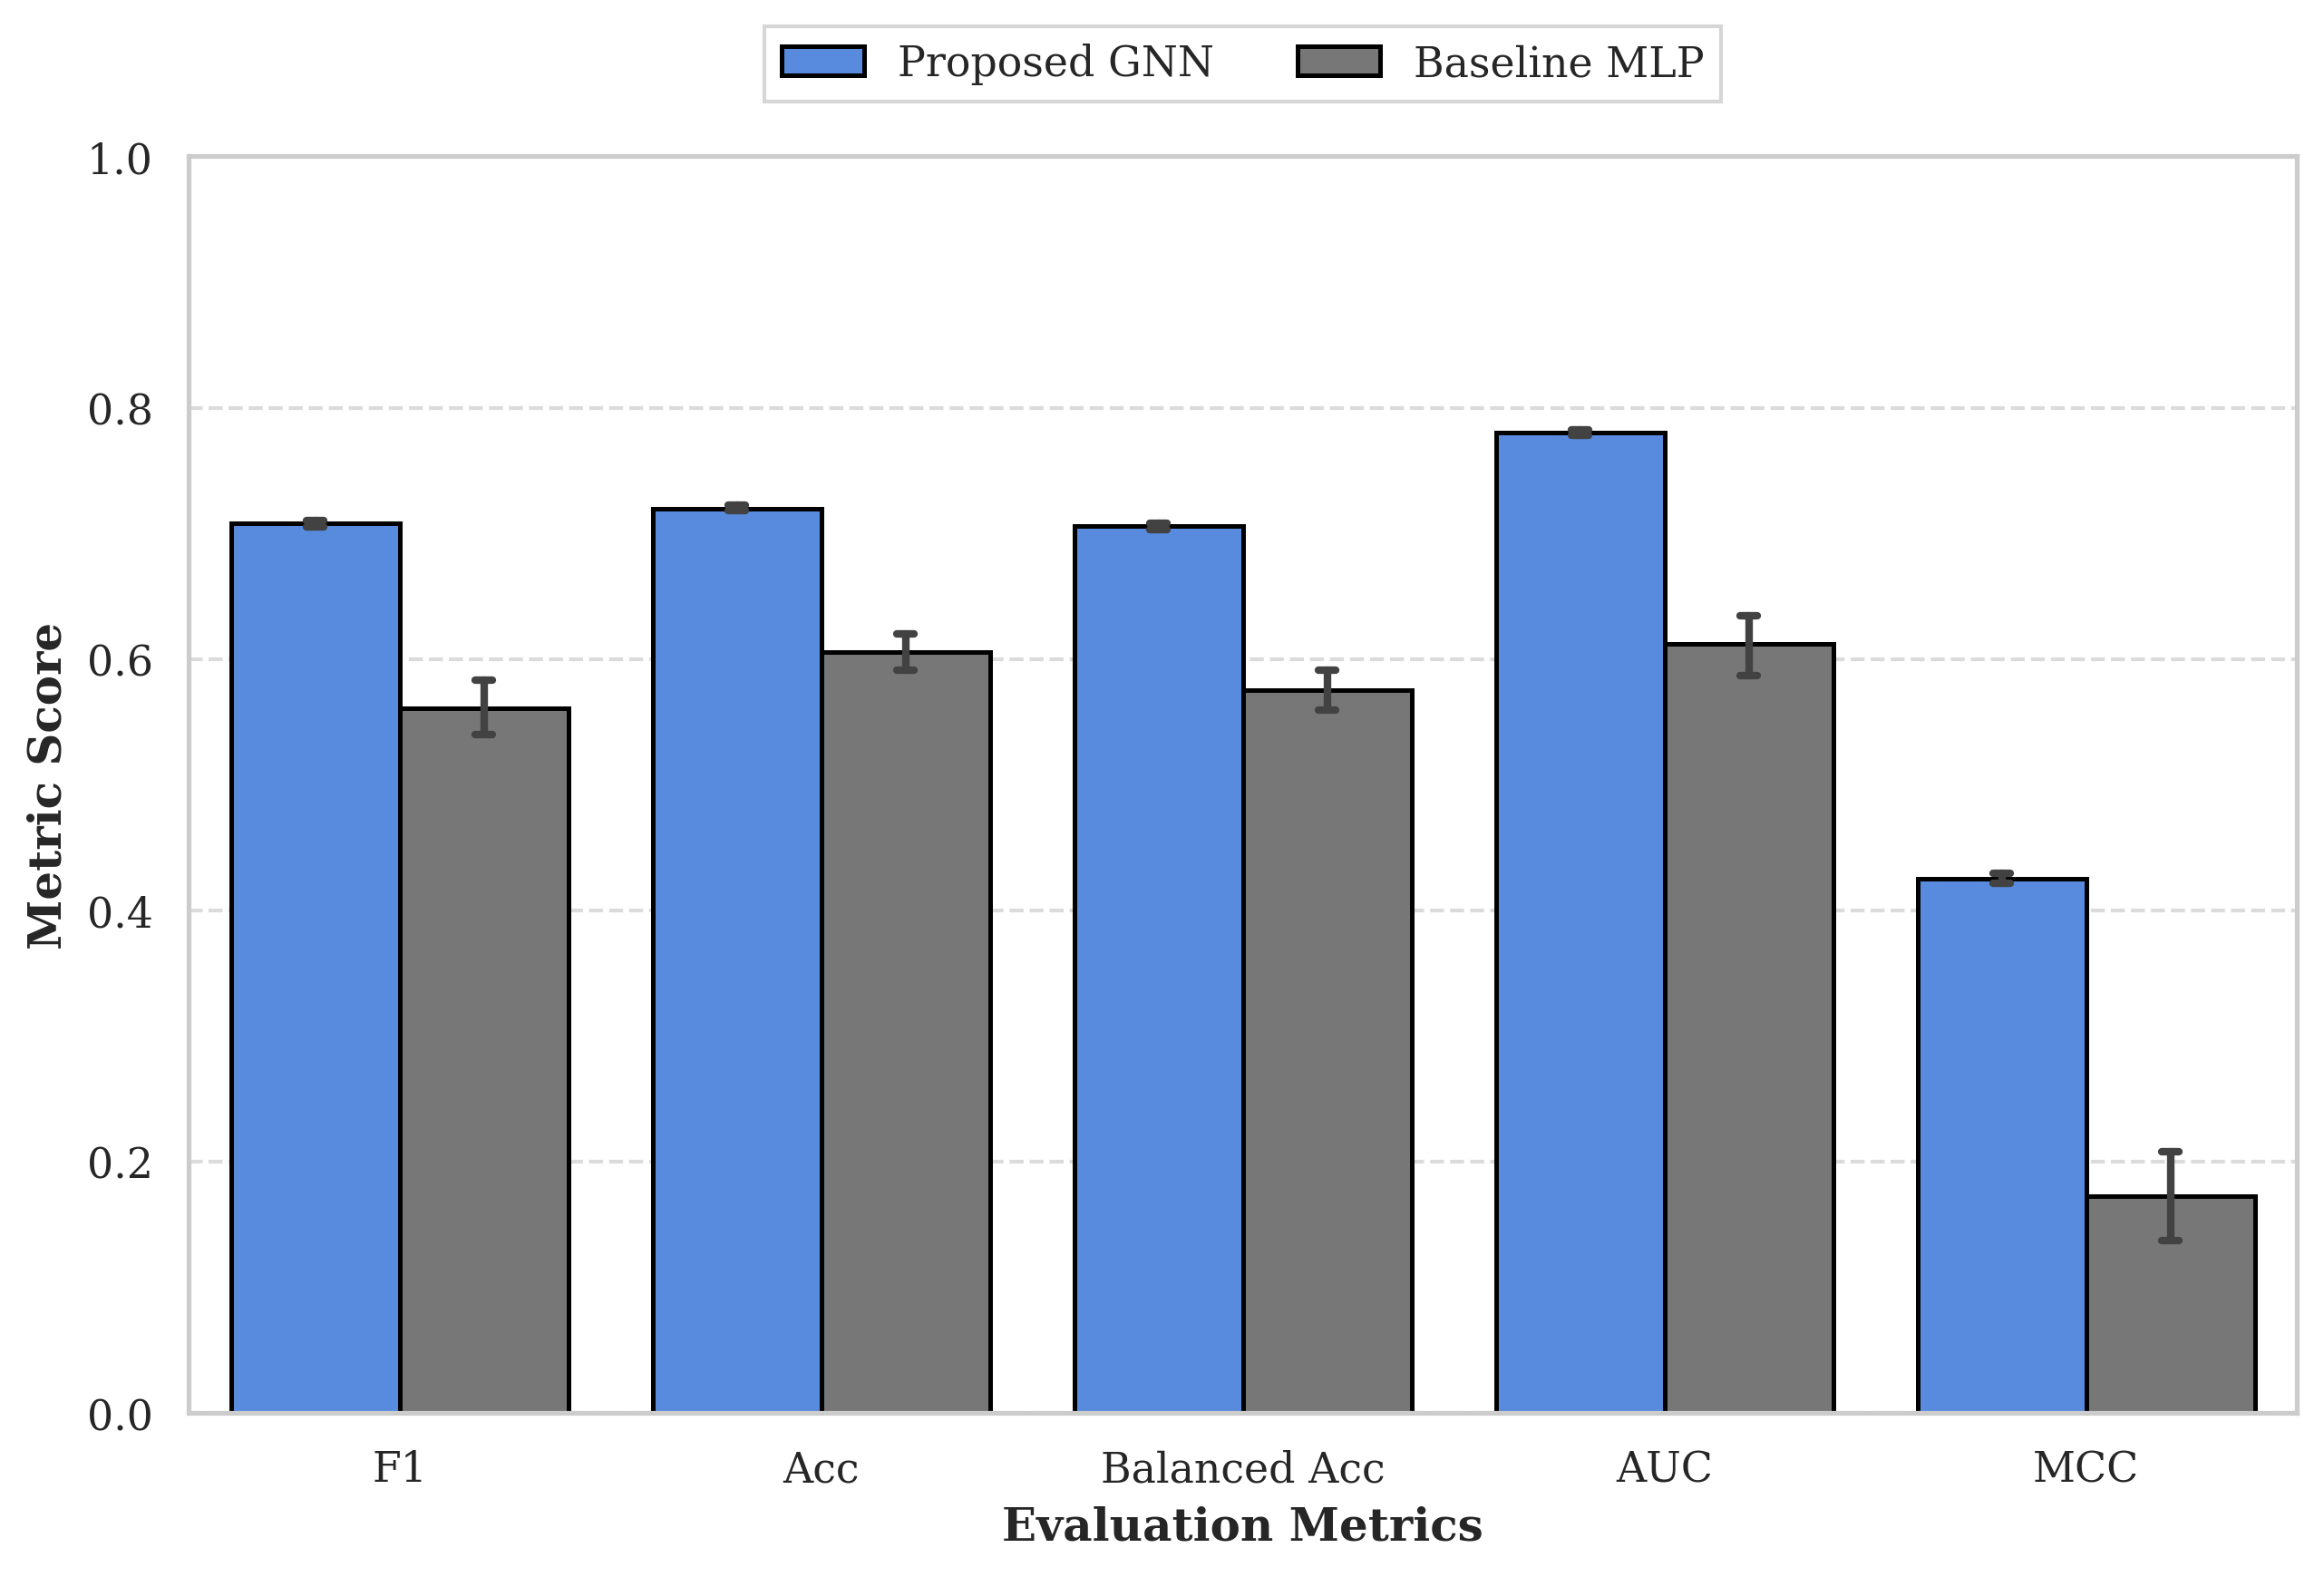


--- Final showdown plots saved to ./outputs\figures ---


In [23]:
plot_final_showdown(showdown_results_no_collapse, "no_collapse_", OUTPUT_FIGURES_PATH)

## Best MLP vs Best GNN (Full Node Features With Seasonal Features Included): Multi-Metric Comparison

In [ ]:
x, y, pos_combined, pos_spatial, pos_temporal, group_ids = prepare_dataset(DATA_PATH, return_group_ids=True, seasonal_features=True)

x_mlp_spatial = torch.cat([x, pos_spatial], dim=1)        
x_mlp_temporal = torch.cat([x, pos_temporal], dim=1)        
x_mlp_combined = torch.cat([x, pos_spatial, pos_temporal], dim=1) 

In [ ]:
showdown_results_seasonal, summary_seasonal = run_automated_showdown(
    "best_full_features_seasonal",
    best_transformer_df, 
    mlp_topology_comparison_df, 
    x_mlp_combined, 
    x_mlp_spatial, 
    x_mlp_temporal, 
    num_runs=5
)

print("\n[SUMMARY TABLE]")
best_mlp_vs_full_feature_best_gnn_seasonal_df = pd.DataFrame(summary_seasonal, index=['GNN_Mean', 'GNN_SD', 'MLP_Mean', 'MLP_SD']).T
best_mlp_vs_full_feature_best_gnn_seasonal_df.to_csv(os.path.join(OUTPUT_TABLES_PATH, "best_mlp_vs_full_feature_best_gnn_seasonal_df.csv"))

In [ ]:
plot_final_showdown(showdown_results_seasonal, "seasonal_", OUTPUT_FIGURES_PATH)